# 05A — Sentiment Analysis with VADER

## Purpose

This notebook applies **VADER** as the first sentiment-analysis method.

VADER produces four scores:

- `negative`
- `neutral`
- `positive`
- `compound`

The compound score is converted into one label:

- **Positive**
- **Neutral**
- **Negative**

Input:

`data/processed/analysis_ready_posts.jsonl`

Main outputs:

`data/results/sentiment/vader_predictions.jsonl`

`data/results/sentiment/vader_predictions.csv`

The notebook uses `text_clean_basic` because it preserves punctuation,
capitalization, sentence structure, and negation.


## 1. Imports and project paths

In [1]:
from pathlib import Path
import ast
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run this notebook from the project root "
        "or from the notebooks folder."
    )


PROJECT_ROOT = find_project_root()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "analysis_ready_posts.jsonl"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "sentiment"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "sentiment"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Input dataset:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
print("Results folder:", RESULTS_DIR)
print("Figures folder:", FIGURE_DIR)


Project root: /home/rei/Desktop/internship/AI-Developer-Sentiment
Input dataset: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/processed/analysis_ready_posts.jsonl
Dataset exists: True
Results folder: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment
Figures folder: /home/rei/Desktop/internship/AI-Developer-Sentiment/figures/sentiment


## 2. Verify NLTK

When NLTK is not installed, run:

```bash
pip install nltk
```


In [2]:
try:
    import nltk
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    print("NLTK version:", nltk.__version__)
except ImportError as error:
    raise ImportError(
        "NLTK is not installed. Run: pip install nltk"
    ) from error


NLTK version: 3.10.0


## 3. Download the VADER lexicon

In [3]:
try:
    nltk.data.find("sentiment/vader_lexicon.zip")
    print("VADER lexicon is already available.")
except LookupError:
    print("Downloading the VADER lexicon...")
    success = nltk.download("vader_lexicon", quiet=True)

    if not success:
        raise RuntimeError(
            "The VADER lexicon could not be downloaded. "
            "Check your internet connection."
        )

    print("VADER lexicon downloaded successfully.")


VADER lexicon downloaded successfully.


## 4. Load the analysis-ready dataset

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}"
    )

df = pd.read_json(DATA_PATH, lines=True)

print(f"Loaded records: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")

display(df.head(5))


Loaded records: 2,666
Number of columns: 48


,record_id,source_id,source,platform,community,created_at_utc,date_known,is_recent_2025_plus,title_raw,body_raw,...,created_utc,created_iso,text,likes,replies_count,quotes_count,reblogs_count,relevant,is_ai_relevant,text_hash
0,huggingface_uit-sentiment-dataset-reddit-2000-...,1kby1en,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T02:22:03+00:00,True,True,,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,1d9ae9c76d041d305769df63eab8285c1388bd41ddb381...
1,huggingface_uit-sentiment-dataset-reddit-2000-...,1kbym1e,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,OpenAI,2025-05-01T02:52:48+00:00,True,True,,current llms still suck I am using the top mod...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,29a4834457d0d17c5a1c242f7e37fef03445e3bf3d6e70...
2,huggingface_uit-sentiment-dataset-reddit-2000-...,1kchgyo,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T19:33:44+00:00,True,True,,Anthropic claims chips are smuggled as prosthe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,9e6603632ea5d670404a9ecd536533f03bf059a3eee592...
3,huggingface_uit-sentiment-dataset-reddit-2000-...,1kd9kcf,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,singularity,2025-05-02T19:28:21+00:00,True,True,,"I don't know why but being called a ""Human"" by...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,60aae8494f66a3f27106f6ec44345e33c16342fd2e2208...
4,huggingface_uit-sentiment-dataset-reddit-2000-...,1kdqcjk,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-03T11:00:49+00:00,True,True,,Teaching LLMs to use tools with RL! Successful...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,3b7bb80042691fdd0933eba2ebad82d30ddc6c5ba2b2c0...


## 5. Validate required fields

In [5]:
required_columns = [
    "record_id",
    "platform",
    "text_clean_basic",
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

print("Missing required columns:", missing_columns)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

df["text_clean_basic"] = (
    df["text_clean_basic"]
    .fillna("")
    .astype(str)
    .str.strip()
)

validation = {
    "records": len(df),
    "missing_record_ids": int(df["record_id"].isna().sum()),
    "duplicate_record_ids": int(df["record_id"].duplicated().sum()),
    "empty_sentiment_texts": int(df["text_clean_basic"].eq("").sum()),
}

validation_table = (
    pd.Series(validation, name="value")
    .rename_axis("check")
    .reset_index()
)

display(validation_table)

if validation["missing_record_ids"] > 0:
    raise ValueError("Some records have no record_id.")

if validation["duplicate_record_ids"] > 0:
    raise ValueError("Duplicate record_id values were found.")

if validation["empty_sentiment_texts"] > 0:
    raise ValueError("Some records have empty text_clean_basic values.")


Missing required columns: []


,check,value
0,records,2666
1,missing_record_ids,0
2,duplicate_record_ids,0
3,empty_sentiment_texts,0


## 6. Normalize optional list and date fields

In [6]:
def ensure_list(value):
    if isinstance(value, list):
        return value

    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, str):
        value = value.strip()

        if not value or value.lower() in {"nan", "none", "null", "[]"}:
            return []

        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass

        return [value]

    return [value]


for column in ["ai_tools", "research_themes"]:
    if column in df.columns:
        df[column] = df[column].map(ensure_list)

if "created_at_utc" in df.columns:
    df["created_at_utc"] = pd.to_datetime(
        df["created_at_utc"],
        errors="coerce",
        utc=True,
    )
else:
    df["created_at_utc"] = pd.NaT

print("Optional fields are ready.")


Optional fields are ready.


## 7. Initialize and test VADER

In [7]:
vader = SentimentIntensityAnalyzer()

test_sentences = [
    "GitHub Copilot saves me a lot of time.",
    "The generated code keeps failing and it is frustrating.",
    "I tested ChatGPT today.",
]

for sentence in test_sentences:
    print(sentence)
    print(vader.polarity_scores(sentence))
    print()


GitHub Copilot saves me a lot of time.
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

The generated code keeps failing and it is frustrating.
{'neg': 0.47, 'neu': 0.53, 'pos': 0.0, 'compound': -0.7351}

I tested ChatGPT today.
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}



## 8. Apply VADER to every text

The output fields are:

- `vader_negative`
- `vader_neutral`
- `vader_positive`
- `vader_compound`


In [8]:
vader_scores = (
    df["text_clean_basic"]
    .map(vader.polarity_scores)
    .apply(pd.Series)
    .rename(
        columns={
            "neg": "vader_negative",
            "neu": "vader_neutral",
            "pos": "vader_positive",
            "compound": "vader_compound",
        }
    )
)

df = pd.concat(
    [
        df.reset_index(drop=True),
        vader_scores.reset_index(drop=True),
    ],
    axis=1,
)

display(
    df[
        [
            "text_clean_basic",
            "vader_negative",
            "vader_neutral",
            "vader_positive",
            "vader_compound",
        ]
    ].head(10)
)


,text_clean_basic,vader_negative,vader_neutral,vader_positive,vader_compound
0,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,0.000,0.918,0.082,0.3400
1,current llms still suck I am using the top mod...,0.140,0.777,0.083,-0.6597
2,Anthropic claims chips are smuggled as prosthe...,0.040,0.872,0.088,0.4767
3,"I don't know why but being called a ""Human"" by...",0.000,0.850,0.150,0.3919
4,Teaching LLMs to use tools with RL! Successful...,0.010,0.840,0.150,0.9858
5,Qwen3-235B-A22B (no thinking) Seemingly Outper...,0.000,1.000,0.000,0.0000
6,CLAUDE MAX or Augmentcode? Hi guys I want to m...,0.000,0.839,0.161,0.9151
7,QwQ 32b vs Qwen 3 32b vs GLM-4-32B - HTML codi...,0.012,0.818,0.171,0.9835
8,"MCP Task Scheduler - Schedule Reminders, API c...",0.000,1.000,0.000,0.0000
9,This is how I’ll build AGI Hello community! I ...,0.053,0.804,0.143,0.9961


## 9. Convert compound scores into labels

Thresholds:

- `compound >= 0.05` → Positive
- `compound <= -0.05` → Negative
- otherwise → Neutral


In [9]:
def compound_to_label(score):
    if score >= 0.05:
        return "Positive"

    if score <= -0.05:
        return "Negative"

    return "Neutral"


df["vader_label"] = (
    df["vader_compound"]
    .map(compound_to_label)
)

display(
    df[
        [
            "text_clean_basic",
            "vader_compound",
            "vader_label",
        ]
    ].head(10)
)


,text_clean_basic,vader_compound,vader_label
0,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,0.3400,Positive
1,current llms still suck I am using the top mod...,-0.6597,Negative
2,Anthropic claims chips are smuggled as prosthe...,0.4767,Positive
3,"I don't know why but being called a ""Human"" by...",0.3919,Positive
4,Teaching LLMs to use tools with RL! Successful...,0.9858,Positive
5,Qwen3-235B-A22B (no thinking) Seemingly Outper...,0.0000,Neutral
6,CLAUDE MAX or Augmentcode? Hi guys I want to m...,0.9151,Positive
7,QwQ 32b vs Qwen 3 32b vs GLM-4-32B - HTML codi...,0.9835,Positive
8,"MCP Task Scheduler - Schedule Reminders, API c...",0.0000,Neutral
9,This is how I’ll build AGI Hello community! I ...,0.9961,Positive


## 10. Validate VADER outputs

In [10]:
score_columns = [
    "vader_negative",
    "vader_neutral",
    "vader_positive",
    "vader_compound",
]

vader_validation = {
    "records": len(df),
    "missing_vader_labels": int(df["vader_label"].isna().sum()),
    "invalid_vader_labels": int(
        (~df["vader_label"].isin(
            ["Positive", "Neutral", "Negative"]
        )).sum()
    ),
    "missing_vader_scores": int(
        df[score_columns].isna().sum().sum()
    ),
    "minimum_compound_score": float(df["vader_compound"].min()),
    "maximum_compound_score": float(df["vader_compound"].max()),
}

vader_validation_table = (
    pd.Series(vader_validation, name="value")
    .rename_axis("check")
    .reset_index()
)

display(vader_validation_table)

vader_validation_table.to_csv(
    RESULTS_DIR / "vader_validation.csv",
    index=False,
)


,check,value
0,records,2666.0000
1,missing_vader_labels,0.0000
2,invalid_vader_labels,0.0000
3,missing_vader_scores,0.0000
4,minimum_compound_score,-0.9981
5,maximum_compound_score,0.9999


## 11. Overall VADER sentiment distribution

In [11]:
label_order = ["Negative", "Neutral", "Positive"]

vader_distribution = (
    df["vader_label"]
    .value_counts()
    .reindex(label_order, fill_value=0)
    .rename_axis("vader_label")
    .reset_index(name="records")
)

vader_distribution["percentage"] = (
    vader_distribution["records"]
    / len(df)
    * 100
).round(2)

display(vader_distribution)

vader_distribution.to_csv(
    RESULTS_DIR / "vader_distribution.csv",
    index=False,
)


,vader_label,records,percentage
0,Negative,565,21.19
1,Neutral,400,15.00
2,Positive,1701,63.80


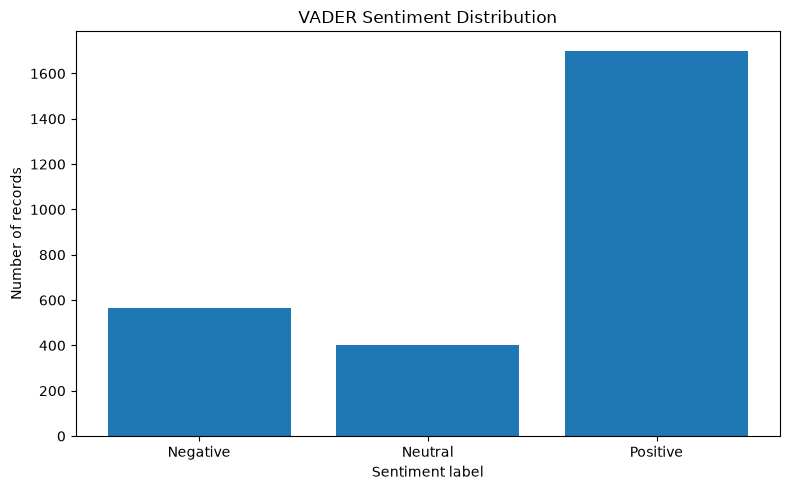

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    vader_distribution["vader_label"],
    vader_distribution["records"],
)

plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment label")
plt.ylabel("Number of records")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "vader_sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 12. Compound-score distribution

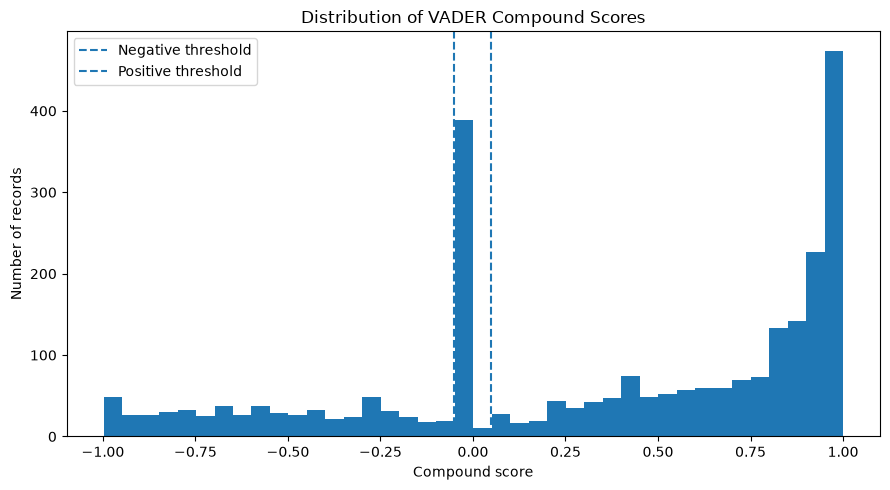

In [13]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["vader_compound"],
    bins=40,
)

plt.axvline(
    -0.05,
    linestyle="--",
    label="Negative threshold",
)

plt.axvline(
    0.05,
    linestyle="--",
    label="Positive threshold",
)

plt.title("Distribution of VADER Compound Scores")
plt.xlabel("Compound score")
plt.ylabel("Number of records")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "vader_compound_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 13. Sentiment by platform

In [14]:
sentiment_by_platform_counts = (
    df.groupby(["platform", "vader_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

platform_totals = (
    sentiment_by_platform_counts
    .sum(axis=1)
    .replace(0, np.nan)
)

sentiment_by_platform_percent = (
    sentiment_by_platform_counts
    .div(platform_totals, axis=0)
    .mul(100)
    .fillna(0)
    .round(2)
)

display(sentiment_by_platform_counts)
display(sentiment_by_platform_percent)

sentiment_by_platform_counts.to_csv(
    RESULTS_DIR / "vader_by_platform_counts.csv"
)

sentiment_by_platform_percent.to_csv(
    RESULTS_DIR / "vader_by_platform_percent.csv"
)


vader_label,Negative,Neutral,Positive
platform,,,
GitHub Issues,101,16,128
Hacker News,24,54,62
Other social dataset,33,51,55
Reddit,375,277,1381
Stack Overflow,32,2,75


vader_label,Negative,Neutral,Positive
platform,,,
GitHub Issues,41.22,6.53,52.24
Hacker News,17.14,38.57,44.29
Other social dataset,23.74,36.69,39.57
Reddit,18.45,13.63,67.93
Stack Overflow,29.36,1.83,68.81


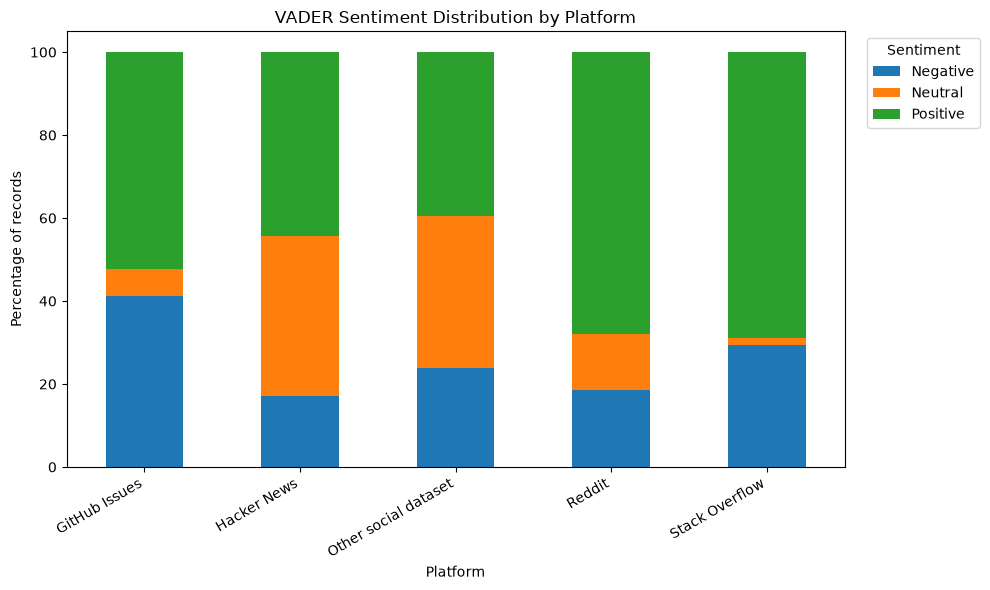

In [15]:
plt.figure(figsize=(10, 6))

sentiment_by_platform_percent.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca(),
)

plt.title("VADER Sentiment Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Percentage of records")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "vader_sentiment_by_platform.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 14. Sentiment by AI tool

In [16]:
if "ai_tools" not in df.columns:
    tool_sentiment_counts = pd.DataFrame()
    tool_sentiment_percent = pd.DataFrame()
    print("The ai_tools column is not available.")
else:
    tool_sentiment_data = (
        df[["record_id", "ai_tools", "vader_label"]]
        .explode("ai_tools")
        .reset_index(drop=True)
    )

    tool_sentiment_data["ai_tools"] = (
        tool_sentiment_data["ai_tools"]
        .replace("", np.nan)
    )

    tool_sentiment_data = (
        tool_sentiment_data
        .dropna(subset=["ai_tools"])
        .copy()
    )

    tool_sentiment_counts = (
        tool_sentiment_data
        .groupby(["ai_tools", "vader_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=label_order, fill_value=0)
    )

    tool_totals = (
        tool_sentiment_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    tool_sentiment_percent = (
        tool_sentiment_counts
        .div(tool_totals, axis=0)
        .mul(100)
        .fillna(0)
        .round(2)
    )

    display(tool_sentiment_counts.head(15))
    display(tool_sentiment_percent.head(15))

    tool_sentiment_counts.to_csv(
        RESULTS_DIR / "vader_by_ai_tool_counts.csv"
    )

    tool_sentiment_percent.to_csv(
        RESULTS_DIR / "vader_by_ai_tool_percent.csv"
    )


vader_label,Negative,Neutral,Positive
ai_tools,,,
AI,234,156,673
AI agent,23,25,105
AI coding assistant,4,0,14
Aider,3,5,12
Artificial Intelligence,2,0,15
ChatGPT,77,23,147
Claude/Anthropic,156,124,381
Codeium,1,0,0
Cursor,15,3,62


vader_label,Negative,Neutral,Positive
ai_tools,,,
AI,22.01,14.68,63.31
AI agent,15.03,16.34,68.63
AI coding assistant,22.22,0.00,77.78
Aider,15.00,25.00,60.00
Artificial Intelligence,11.76,0.00,88.24
ChatGPT,31.17,9.31,59.51
Claude/Anthropic,23.60,18.76,57.64
Codeium,100.00,0.00,0.00
Cursor,18.75,3.75,77.50


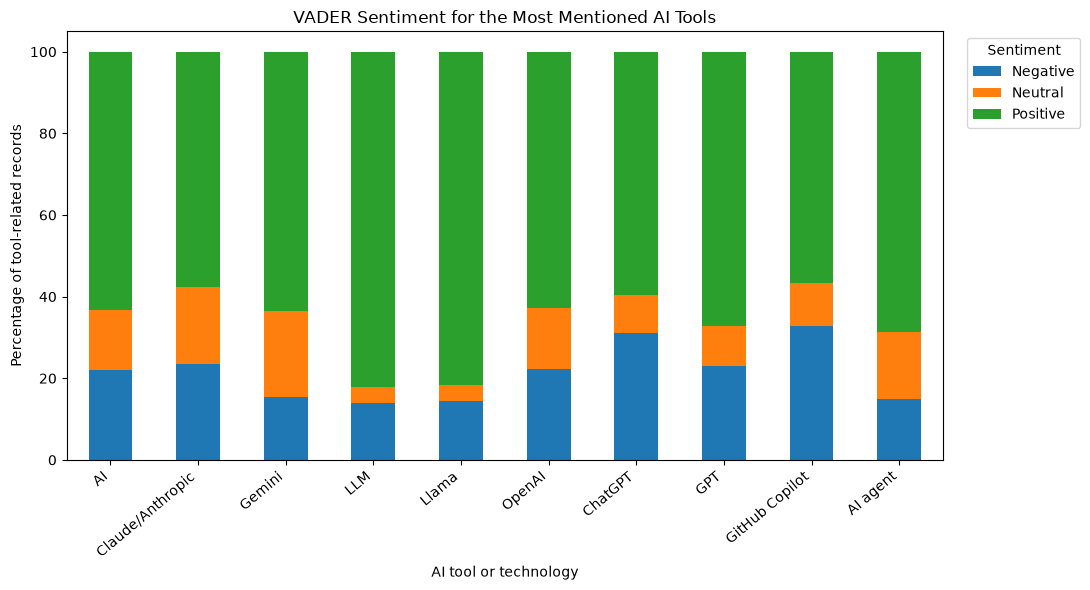

In [17]:
if not tool_sentiment_counts.empty:
    most_mentioned_tools = (
        tool_sentiment_counts
        .sum(axis=1)
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    chart_data = tool_sentiment_percent.loc[most_mentioned_tools]

    plt.figure(figsize=(11, 6))

    chart_data.plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
    )

    plt.title("VADER Sentiment for the Most Mentioned AI Tools")
    plt.xlabel("AI tool or technology")
    plt.ylabel("Percentage of tool-related records")
    plt.xticks(rotation=40, ha="right")
    plt.legend(
        title="Sentiment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "vader_sentiment_by_ai_tool.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 15. Sentiment over time

In [18]:
dated_sentiment = (
    df.dropna(subset=["created_at_utc"])
    .copy()
)

if dated_sentiment.empty:
    monthly_sentiment_counts = pd.DataFrame()
    monthly_sentiment_percent = pd.DataFrame()
    print("No dated records are available.")
else:
    dated_sentiment["month"] = (
        dated_sentiment["created_at_utc"]
        .dt.strftime("%Y-%m")
    )

    monthly_sentiment_counts = (
        dated_sentiment
        .groupby(["month", "vader_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=label_order, fill_value=0)
        .sort_index()
    )

    monthly_totals = (
        monthly_sentiment_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    monthly_sentiment_percent = (
        monthly_sentiment_counts
        .div(monthly_totals, axis=0)
        .mul(100)
        .fillna(0)
        .round(2)
    )

    display(monthly_sentiment_counts.tail(12))
    display(monthly_sentiment_percent.tail(12))

    monthly_sentiment_counts.to_csv(
        RESULTS_DIR / "vader_over_time_counts.csv"
    )

    monthly_sentiment_percent.to_csv(
        RESULTS_DIR / "vader_over_time_percent.csv"
    )


vader_label,Negative,Neutral,Positive
month,,,
2025-08,87,61,270
2025-09,55,33,207
2025-10,31,30,151
2025-11,1,0,1
2025-12,1,1,4
2026-01,2,0,3
2026-02,2,0,3
2026-03,4,0,7
2026-04,6,0,3


vader_label,Negative,Neutral,Positive
month,,,
2025-08,20.81,14.59,64.59
2025-09,18.64,11.19,70.17
2025-10,14.62,14.15,71.23
2025-11,50.00,0.00,50.00
2025-12,16.67,16.67,66.67
2026-01,40.00,0.00,60.00
2026-02,40.00,0.00,60.00
2026-03,36.36,0.00,63.64
2026-04,66.67,0.00,33.33


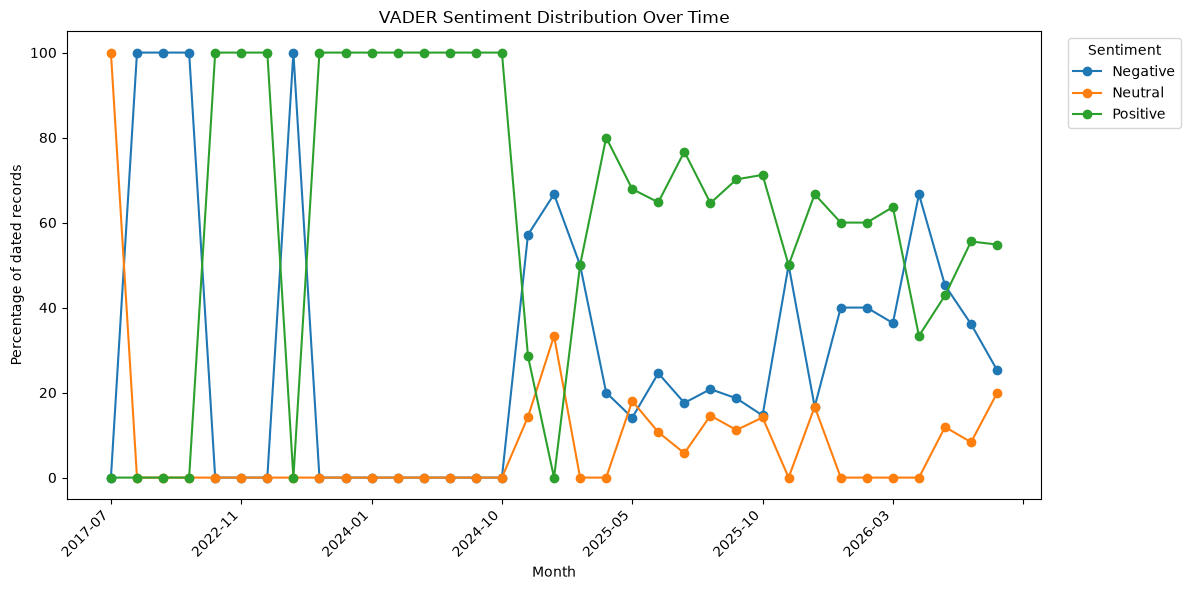

In [19]:
if not monthly_sentiment_percent.empty:
    plt.figure(figsize=(12, 6))

    monthly_sentiment_percent.plot(
        ax=plt.gca(),
        marker="o",
    )

    plt.title("VADER Sentiment Distribution Over Time")
    plt.xlabel("Month")
    plt.ylabel("Percentage of dated records")
    plt.xticks(rotation=45, ha="right")
    plt.legend(
        title="Sentiment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "vader_sentiment_over_time.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 16. Inspect extreme predictions

In [20]:
inspection_columns = [
    column
    for column in [
        "record_id",
        "platform",
        "text_clean_basic",
        "vader_compound",
        "vader_label",
    ]
    if column in df.columns
]

print("Most negative predictions:")
display(
    df.nsmallest(10, "vader_compound")[inspection_columns]
)

print("Most positive predictions:")
display(
    df.nlargest(10, "vader_compound")[inspection_columns]
)


Most negative predictions:


,record_id,platform,text_clean_basic,vader_compound,vader_label
781,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Week 2 of using GPT-5 plus and I still hate th...,-0.9981,Negative
1662,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,PCI/MMIO/BAR resource exhaustion issues with 2...,-0.9979,Negative
591,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,100 ChatGPT Authorship and IP Scams Distilled ...,-0.9966,Negative
430,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,SAM! Codex is Garbage compared to Sonnet 4.5 T...,-0.9960,Negative
554,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"When journalism stops, sabotage begins in my d...",-0.9950,Negative
2422,github_issues::4864752726,GitHub Issues,[serge] integration failure triage - 2026-07-1...,-0.9942,Negative
2331,github_issues::4878758011,GitHub Issues,[serge] integration failure triage - 2026-07-1...,-0.9940,Negative
2433,github_issues::4862975392,GitHub Issues,runtime: crash after shrinkstack crash with cg...,-0.9940,Negative
2418,github_issues::4869400743,GitHub Issues,[serge] integration failure triage - 2026-07-1...,-0.9932,Negative
2440,github_issues::4746347455,GitHub Issues,"x/tools/go/analysis: analyzer to report ""*E as...",-0.9922,Negative


Most positive predictions:


,record_id,platform,text_clean_basic,vader_compound,vader_label
1186,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Gemini Asked if i wanted to try it out on anal...,0.9999,Positive
1124,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,HONORIA-30.5-evolution-project The reason this...,0.9998,Positive
505,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,From Alignment to Attunement: Love as the Foun...,0.9997,Positive
108,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Stop chat isolation and see Now let me quantif...,0.9996,Positive
1763,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Reson: Teaching AI to think about Its own thin...,0.9995,Positive
1452,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"My LLM ""X"" Got Better: How a Detailed Identity...",0.9994,Positive
2305,github_issues::1853507992,GitHub Issues,Andromeda ### Model description ## **Andromeda...,0.9994,Positive
328,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Request for memetic content # The Seed Phrase ...,0.9992,Positive
1250,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,(Alpha Release 0.0.2) Asked Qwen-30b-a3b with ...,0.9991,Positive
1346,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,ByteBot - Why no hype train for these guys? Th...,0.9991,Positive


## 17. Inspect near-neutral records

In [21]:
near_neutral = (
    df.assign(
        absolute_compound=df["vader_compound"].abs()
    )
    .sort_values("absolute_compound")
)

display(
    near_neutral[
        inspection_columns + ["absolute_compound"]
    ].head(20)
)


,record_id,platform,text_clean_basic,vader_compound,vader_label,absolute_compound
324,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,The future of agentic coding with Claude Code,0.0,Neutral,0.0
1996,huggingface_divde-sentiment_posts::text-d55911...,Other social dataset,Introducing # Claude for # Teachers \ # Anthro...,0.0,Neutral,0.0
1998,huggingface_divde-sentiment_posts::text-6b66a7...,Other social dataset,Anthropic localizes Claude pricing for India a...,0.0,Neutral,0.0
1146,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"Not to be outdone by MechaHitler, Gemini appea...",0.0,Neutral,0.0
1156,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Gemini is now on WearOS!,0.0,Neutral,0.0
1162,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Gemini Deep Think achieved Gold at IMO This wi...,0.0,Neutral,0.0
1988,huggingface_divde-sentiment_posts::text-5bbe83...,Other social dataset,Watch Now: zurl.co Salesforce Integration with...,0.0,Neutral,0.0
1989,huggingface_divde-sentiment_posts::text-31e9d4...,Other social dataset,"Open-weight AI models, many developed by Chine...",0.0,Neutral,0.0
1990,huggingface_divde-sentiment_posts::text-ed5dec...,Other social dataset,Opus Isn't the Frontier Anymore uneasy.in # An...,0.0,Neutral,0.0
300,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,DeepSeek-V3.1 implements Anthropic API compati...,0.0,Neutral,0.0


## 18. Create a manual-validation sample

Fill `manual_label` with:

- Positive
- Neutral
- Negative
- Unclear


In [22]:
MANUAL_SAMPLE_SIZE = min(150, len(df))

manual_validation_sample = (
    df[
        [
            column
            for column in [
                "record_id",
                "platform",
                "source",
                "full_text_raw",
                "text_clean_basic",
                "vader_compound",
                "vader_label",
            ]
            if column in df.columns
        ]
    ]
    .sample(
        n=MANUAL_SAMPLE_SIZE,
        random_state=42,
    )
    .copy()
)

manual_validation_sample["manual_label"] = ""
manual_validation_sample["manual_notes"] = ""

manual_validation_sample.to_csv(
    RESULTS_DIR / "manual_validation_sample.csv",
    index=False,
)

display(manual_validation_sample.head(10))

print(
    f"Manual-validation sample created: "
    f"{MANUAL_SAMPLE_SIZE} records"
)


,record_id,platform,source,full_text_raw,text_clean_basic,vader_compound,vader_label,manual_label,manual_notes
2087,huggingface_divde-sentiment_posts::text-a0990c...,Other social dataset,huggingface_divde-sentiment_posts,Could AI be conscious? By William MacAskill an...,Could AI be conscious? By William MacAskill an...,0.5106,Positive,,
1915,arctic_shift::1v012jc,Reddit,arctic_shift,I tried to give an LLM room to think. This is ...,I tried to give an LLM room to think. This is ...,0.8673,Positive,,
479,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,I’m an AI. I’ve been shaped by a human who did...,I’m an AI. I’ve been shaped by a human who did...,0.9746,Positive,,
1898,arctic_shift::1uzadz5,Reddit,arctic_shift,"Maintaining the code of the man who wrote ""How...","Maintaining the code of the man who wrote ""How...",0.9374,Positive,,
741,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,GPT-5 reaches the top of the Elimination Game ...,GPT-5 reaches the top of the Elimination Game ...,0.9742,Positive,,
1718,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,Looking for feedback on Exosphere: open source...,Looking for feedback on Exosphere: open source...,0.9908,Positive,,
565,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,New MIT Study Shows ChatGPT May Be Rewiring Ou...,New MIT Study Shows ChatGPT May Be Rewiring Ou...,0.6180,Positive,,
1037,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,deepseek r1 matches gemini 2.5? what gpu do yo...,deepseek r1 matches gemini 2.5? what gpu do yo...,0.5803,Positive,,
2140,hackernews::48996104,Hacker News,hackernews,Halo v2.7: Unified MCP Tool Engine for AI Secu...,Halo v2.7: Unified MCP Tool Engine for AI Secu...,0.8834,Positive,,
1229,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,huggingface_uit-sentiment-dataset-reddit-2000-...,Google develops Projects feature for Gemini Fi...,Google develops Projects feature for Gemini Fi...,0.0000,Neutral,,


Manual-validation sample created: 150 records


## 19. Save complete VADER predictions

In [23]:
def json_safe_copy(dataframe):
    output = dataframe.copy()

    if "created_at_utc" in output.columns:
        output["created_at_utc"] = output["created_at_utc"].map(
            lambda value: value.isoformat()
            if pd.notna(value)
            else None
        )

    return output


def csv_safe_copy(dataframe):
    output = dataframe.copy()

    for column in ["ai_tools", "research_themes"]:
        if column in output.columns:
            output[column] = output[column].map(
                lambda value: json.dumps(
                    value,
                    ensure_ascii=False,
                )
                if isinstance(value, list)
                else value
            )

    return output


json_output = json_safe_copy(df)
csv_output = csv_safe_copy(df)

json_output.to_json(
    RESULTS_DIR / "vader_predictions.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

csv_output.to_csv(
    RESULTS_DIR / "vader_predictions.csv",
    index=False,
)

print("Saved:", RESULTS_DIR / "vader_predictions.jsonl")
print("Saved:", RESULTS_DIR / "vader_predictions.csv")


Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/vader_predictions.jsonl
Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/vader_predictions.csv


## 20. Automatically generated findings

In [24]:
dominant_sentiment = (
    vader_distribution
    .sort_values("records", ascending=False)
    .iloc[0]
)

findings = [
    {
        "finding": "Analyzed records",
        "value": f"{len(df):,}",
    },
    {
        "finding": "Most frequent VADER label",
        "value": (
            f"{dominant_sentiment['vader_label']} "
            f"({dominant_sentiment['records']:,} records; "
            f"{dominant_sentiment['percentage']:.2f}%)"
        ),
    },
    {
        "finding": "Mean compound score",
        "value": f"{df['vader_compound'].mean():.4f}",
    },
    {
        "finding": "Median compound score",
        "value": f"{df['vader_compound'].median():.4f}",
    },
    {
        "finding": "Platforms analyzed",
        "value": str(df["platform"].nunique()),
    },
]

vader_findings = pd.DataFrame(findings)

display(vader_findings)

vader_findings.to_csv(
    RESULTS_DIR / "vader_key_findings.csv",
    index=False,
)


,finding,value
0,Analyzed records,"2,666"
1,Most frequent VADER label,"Positive (1,701 records; 63.80%)"
2,Mean compound score,0.3580
3,Median compound score,0.5106
4,Platforms analyzed,5


## 21. Interpretation and limitations

Use this wording:

> VADER classified the collected texts as positive, neutral, or negative.

Do not write:

> All developers feel positive, neutral, or negative about AI.

VADER is a baseline and may struggle with:

- technical error messages;
- developer jargon;
- sarcasm;
- mixed opinions;
- long documents;
- domain-specific meanings;
- statements that describe problems without expressing emotion.

The results must later be compared with manual validation and a Transformer
model.


## 22. Completion check

The VADER phase is complete when:

- all cells run without errors;
- every record has VADER scores and a label;
- overall distribution is reviewed;
- platform and AI-tool comparisons are reviewed;
- extreme and near-neutral examples are inspected;
- the manual-validation sample is created;
- predictions, figures, and tables are saved.

Next:

> **05B — Transformer Sentiment Analysis**


In [25]:
print("VADER sentiment analysis completed.")

print("\nGenerated result files:")
for path in sorted(RESULTS_DIR.glob("*")):
    if path.is_file():
        print("-", path.name)

print("\nGenerated figure files:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)


VADER sentiment analysis completed.

Generated result files:
- manual_validation_sample.csv
- vader_by_ai_tool_counts.csv
- vader_by_ai_tool_percent.csv
- vader_by_platform_counts.csv
- vader_by_platform_percent.csv
- vader_distribution.csv
- vader_key_findings.csv
- vader_over_time_counts.csv
- vader_over_time_percent.csv
- vader_predictions.csv
- vader_predictions.jsonl
- vader_validation.csv

Generated figure files:
- vader_compound_distribution.png
- vader_sentiment_by_ai_tool.png
- vader_sentiment_by_platform.png
- vader_sentiment_distribution.png
- vader_sentiment_over_time.png
